In [1]:
import itertools 
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

from visualization import (
    bulk_vs_singlecell_matrix_viz,
    loop_heatmap_plots_real_data,
    super_plot_heatmaps_real_data,
    barplot_matches_nonmatches_na,
 )
from accuracy_functions import load_expected_matches_real_data, find_mismatches_real_data
from analysis_shared_functions import (
    parse_heatmap_matrix_hysys,
    parse_heatmap_matrix_crosscheckfingerprints,
)

In [2]:
DATA_PATH = "../../data/output_data/" # Path to the directory containing the data files
FIGURES_PATH = "../../data/figures/" # Path to the directory where the figures will be saved

In [3]:
# Generally all the combinations of these parameters are present in the data, 
# except for BAMixChecker which only has results for read depth 0.
# And occassionally, tools may be missing results because they failed to run for certain combinations of parameters.
tools = ["CrosscheckFingerprints", "HYSYS", "Vireo"]
read_depths_mod1 = [0, 10, 20, 30, 40]
read_depths_mod2 = [0, 10, 20, 30, 40]
datasets = ["hgsoc", "hgsoc-new", "high_grade_glioma", "low_grade_glioma", "wilms_tumor"]

# Sample similarity heatmaps

Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk_10_single-nucleus_10...
Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk_20_single-nucleus_20...
Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk_30_single-nucleus_30...
Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk_40_single-nucleus_40...
Processing tool HYSYS, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool HYSYS, dataset wilms_tumor, read depth bulk_10_single-nucleus_10...
Processing tool HYSYS, dataset wilms_tumor, read depth bulk_20_single-nucleus_20...
Processing tool HYSYS, dataset wilms_tumor, read depth bulk_30_single-nucleus_30...
Processing tool HYSYS, dataset wilms_tumor, read depth bulk_40_single-nucleus_40...
Processing tool Vireo, dataset wilms_tumor, read depth bulk_0_single-nucleus_0.

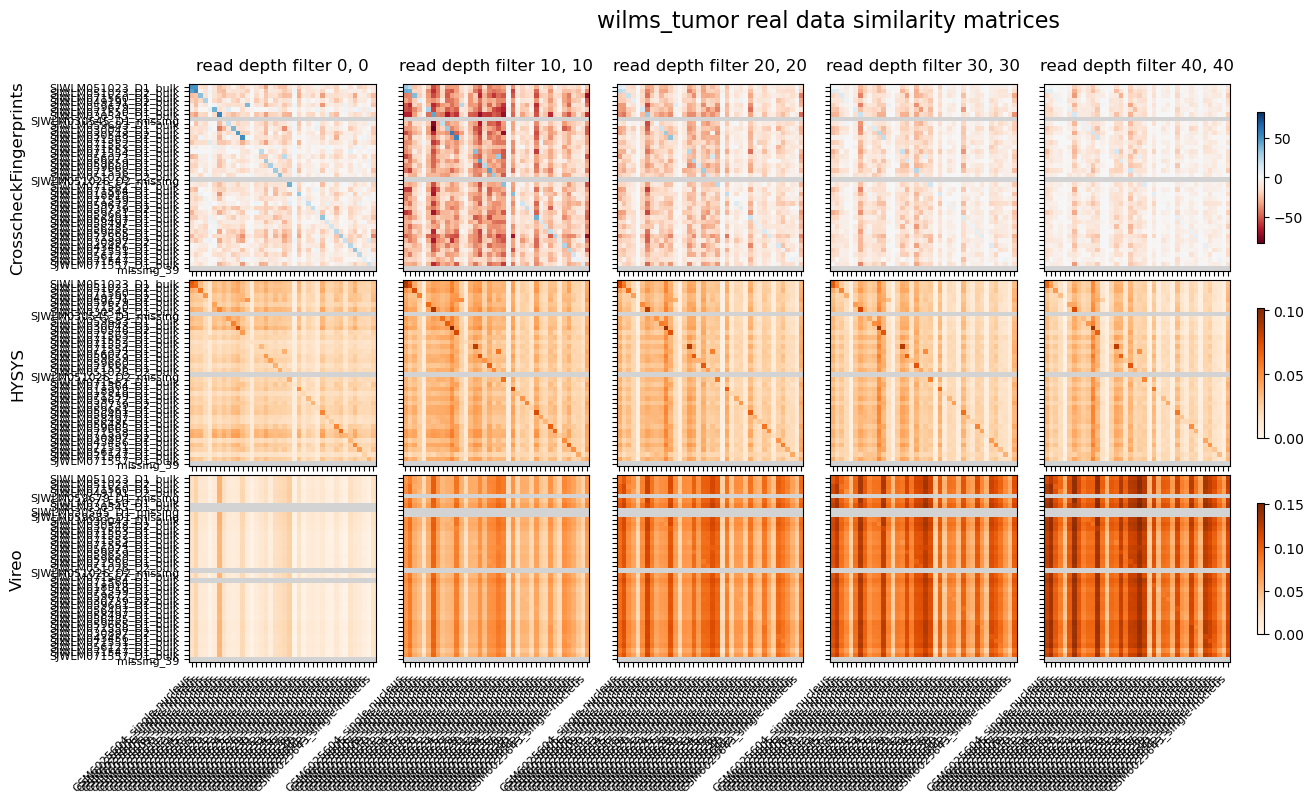

In [ ]:
super_plot_heatmaps_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=tools,
    dataset="wilms_tumor",
    read_depths_mod1=read_depths_mod1,
    read_depths_mod2=read_depths_mod2,
    mod1="bulk",
    mod2="single-nucleus",
    remove_missing_data=True,
    save_fig=True,
)

In [8]:
# To plot an individual heatmap instead use this function
bulk_vs_singlecell_matrix_viz(
    DATA_PATH=DATA_PATH,
    pseudobulk=False,
    tool="Vireo",
    dataset="hgsoc-new",
    ncells="null",
    rd_mod1=0,
    rd_mod2=0,
    mod1="bulk_diss_polyA",
    mod2="pooled_single_cell",
    save_fig=True,
    FIGURES_PATH=FIGURES_PATH,
)

Processing tool Vireo, dataset hgsoc-new, read depth bulk_diss_polyA_0_pooled_single_cell_0...
Could not order by expected matches for requested modalities (bulk_diss_polyA vs pooled_single_cell): Could not resolve expected match columns for requested modalities mod1=bulk_diss_polyA, mod2=pooled_single_cell. Available columns: ['bulk_chunk_ribo sample id', 'bulk_diss_polya sample id']. Falling back to direct modality filtering.


In [5]:
from analysis_shared_functions import load_heatmap_data, order_matrix_by_expected_matches
matrix_df = load_heatmap_data(
        DATA_PATH, False, "Vireo", "hgsoc", "null", "3_56", "bulk_dissociated_polyA", "single-cell"
    )

Processing tool Vireo, dataset hgsoc, read depth 3_56...


In [6]:
expected_matches = load_expected_matches_real_data(DATA_PATH, "hgsoc")
sub_matrix = order_matrix_by_expected_matches(
    matrix_df,
    expected_matches,
    "bulk_dissociated_polyA",
    "single-cell",
)

In [7]:
sub_matrix

,2251_single_cell_single-cell,2267_single_cell_single-cell,2283_single_cell_single-cell,2293_single_cell_single-cell,2380_single_cell_single-cell,2428_single_cell_single-cell,2467_single_cell_single-cell,2497_single_cell_single-cell
2251_bulk_dissociated_polyA_bulk_dissociated_polyA,0.207982,0.209938,0.207206,0.208431,0.210979,0.203666,0.211123,0.210500
2267_bulk_dissociated_polyA_bulk_dissociated_polyA,0.195956,0.197696,0.194957,0.196005,0.198737,0.191427,0.198870,0.198297
2283_bulk_dissociated_polyA_bulk_dissociated_polyA,0.184208,0.185949,0.183134,0.184443,0.186993,0.179694,0.187120,0.186532
2293_bulk_dissociated_polyA_bulk_dissociated_polyA,0.187937,0.189523,0.186973,0.188213,0.190727,0.183413,0.190868,0.190296
2380_bulk_dissociated_polyA_bulk_dissociated_polyA,0.215890,0.217668,0.214951,0.216136,0.218530,0.211388,0.218854,0.218208
2428_bulk_dissociated_polyA_bulk_dissociated_polyA,0.174186,0.175920,0.173197,0.174462,0.176937,0.169559,0.177101,0.176489
2467_bulk_dissociated_polyA_bulk_dissociated_polyA,0.200770,0.202593,0.199840,0.201058,0.203580,0.196262,0.203493,0.203109
2497_bulk_dissociated_polyA_bulk_dissociated_polyA,0.248274,0.250037,0.247275,0.248508,0.250999,0.243737,0.251161,0.250361


In [ ]:
# To plot multiple individual heatmaps use this function
loop_heatmap_plots_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=["Vireo", "HYSYS", "CrosscheckFingerprints"],
    datasets=["hgsoc"],
    read_depths_mod1=[3],
    read_depths_mod2=[25],
    mod1="bulk_dissociated_polyA",
    mod2="single-cell",
)

Processing tool Vireo, dataset hgsoc, read depth 3_25...
Processing tool HYSYS, dataset hgsoc, read depth 3_25...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 3_25...


# Comparison of inferred and expected sample matches

In [5]:
# # Plot how many matches, non-matches, and NAs there are for each tool across read depths for a given dataset
# barplot_matches_nonmatches_na(
#     DATA_PATH=DATA_PATH, 
#     tools=tools, 
#     dataset="high_grade_glioma", 
#     read_depths=read_depths, 
#     mod1="bulk", 
#     mod2="single-cell", 
#     save_fig=False, 
#     FIGURES_PATH=FIGURES_PATH
#     )

In [30]:
merged_df = find_mismatches_real_data(
    DATA_PATH=DATA_PATH, 
    tool="CrosscheckFingerprints", 
    dataset="wilms_tumor", 
    rd1=0, 
    rd2=0,
    mod1="bulk", 
    mod2="single-nucleus"
)
merged_df


Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk=0, single-nucleus=0...


,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
0,NaN,NaN,SJWLM018918_D1,GSM6025606,bulk,single-nucleus,right_only
1,NaN,NaN,SJWLM018918_D1,GSM6025607,bulk,single-nucleus,right_only
2,NaN,NaN,SJWLM018918_D1,GSM6025608,bulk,single-nucleus,right_only
3,NaN,NaN,SJWLM018918_D1,GSM6025626,bulk,single-nucleus,right_only
4,GSM6025627,SJWLM018918_D1,SJWLM018918_D1,GSM6025627,bulk,single-nucleus,both
...,...,...,...,...,...,...,...
254,GSM6025626,SJWLM071564_D1,SJWLM071564_D1,GSM6025626,bulk,single-nucleus,both
255,NaN,NaN,SJWLM071564_D1,GSM6025628,bulk,single-nucleus,right_only
256,NaN,NaN,SJWLM071564_D1,GSM6025630,bulk,single-nucleus,right_only
257,NaN,NaN,SJWLM071564_D1,GSM6025631,bulk,single-nucleus,right_only


In [38]:
merged_df[merged_df["single-nucleus sample id"].str.contains("623", na=False)]

,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
63,GSM6025623,SJWLM051026_D2,SJWLM051026_D2,GSM6025623,bulk,single-nucleus,both


In [33]:
merged_df[merged_df["match_status"] == "left_only"]

,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
18,GSM6025611,SJWLM030545_D1,NaN,NaN,NaN,NaN,left_only
64,GSM6025624,SJWLM051026_D2,NaN,NaN,NaN,NaN,left_only
69,GSM6025619,SJWLM056073_D1,NaN,NaN,NaN,NaN,left_only
129,GSM6025608,SJWLM059679_D1,NaN,NaN,NaN,NaN,left_only
168,GSM6025616,SJWLM071552_D1,NaN,NaN,NaN,NaN,left_only
258,GSM6025643,<NA>,NaN,NaN,NaN,NaN,left_only


In [29]:
merged_df["bulk sample id"].nunique()

37